In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys

sys.path.insert(0, os.path.dirname(os.getcwd()))
import liset_tk.lists_sessions as lists_sessions
import dutta_test.utils as utils
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Load Data
results_path = os.path.join("spikes", "all_networks_metrics_ripplenet.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Threshold:", sorted(df["Threshold"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 2268 rows from spikes\all_networks_metrics_ripplenet.csv
Columns: ['Session', 'Channel', 'Threshold', 'Model', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples', 'Duration_min']
Threshold: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
0,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_best_random_seed123,78,178,31,0.304688,0.715596,0.427397,35.347436,269,109,10.506607
1,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_best_random_seed456,78,158,31,0.330508,0.715596,0.452174,34.717949,244,109,10.506607
2,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_best_random_seed789,77,189,32,0.289474,0.706422,0.410667,30.353680,277,109,10.506607
3,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_random_seed123,66,99,43,0.400000,0.605505,0.481752,40.259091,171,109,10.506607
4,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_random_seed456,80,180,29,0.307692,0.733945,0.433604,32.437917,271,109,10.506607


In [3]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions

sessions_to_reject={
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        "2025-09-25_12-52-22", # Not a good session to detect ripples
        #  "2025-09-24_11-34-51",
        } #R 
# og_session_set={"2025-09-22_17-55-26", #R
# #                 "2025-09-23_15-50-26", #R
# #                 "2025-09-24_10-24-40", #R
# #                 "2025-09-24_14-22-55", #H
# #                 "2025-09-24_15-13-10", #H
# #                 "2025-09-25_16-41-14"} #R    
# }
sessions_to_reject.update(hfo_sessions)

    # df=df[df["Session"].isin(og_session_set)]

    # # New sessions:

    

df=df[~df["Session"].isin(sessions_to_reject)]
print(df["Session"].unique())
# df=df[~df["Session"].isin(ripple_sessions)]

['2025-09-22_17-42-27' '2025-09-22_17-55-26' '2025-09-23_15-50-26'
 '2025-09-23_16-17-52' '2025-09-24_10-24-40' '2025-09-24_11-34-51'
 '2025-09-24_16-29-07' '2025-09-25_11-21-53' '2025-09-25_16-41-14'
 'Calbai32FPGA_251003_144832' 'Calbai32FPGA_251003_150055'
 'Calb_251209_160255' 'Calb_251210_115904' 'Calb_251210_121141'
 'Calb_251210_122327' 'Calb_251210_162849' 'Calb_251210_164150'
 'Calb_251210_165332' 'Calb_251211_104316' 'Calb_251211_105518'
 'Calb_251211_110650' 'PV01ai32FPGA_250611_115923'
 'PV01ai32FPGA_250611_122326']


In [4]:
# Print summary
print("\n--- Summary by Threshold ---")
summary = df.groupby("Threshold")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Threshold ---


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.8,0.520,0.638,0.598,54.0,30.0,43.5
0.7,0.515,0.530,0.681,61.0,59.0,33.0
0.6,0.500,0.453,0.760,71.5,98.0,26.0
0.9,0.493,0.764,0.475,44.0,12.0,58.0
0.5,0.475,0.392,0.832,84.0,147.5,20.0
0.4,0.446,0.333,0.892,89.0,203.0,15.0
0.3,0.388,0.274,0.924,95.0,301.0,10.0


In [5]:
# Print summary
print("\n--- Summary by Network ---")
for model in df["Model"].unique():
    # print(f"\nModel: {model}")
    model_df = df[df["Model"] == model]
    model_summary = model_df.groupby("Threshold")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3).sort_values(by="F1", ascending=False)
    # display(model_summary)



--- Summary by Network ---


In [6]:
print("\n--- Summary by Network - Threshold = 0.7 ---")
threshold = 0.7 
threshold_df = df[(df["Threshold"] == threshold)]
model_summary = threshold_df.groupby("Model")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3).sort_values(by="F1", ascending=False)
# display(model_summary)


--- Summary by Network - Threshold = 0.7 ---


In [7]:
model_summary = df.groupby(["Model","Threshold"])[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3).sort_values(by="F1", ascending=False)
display(model_summary.head())

,,F1,Precision,Recall,TP,FP,FN
Model,Threshold,,,,,,
ripplenet_unidirectional_best_random_seed456,0.7,0.582,0.774,0.485,47.0,16.0,64.0
ripplenet_unidirectional_best_random_seed123,0.8,0.581,0.792,0.465,47.0,10.0,66.0
ripplenet_unidirectional_random_seed456,0.6,0.563,0.732,0.479,50.0,16.0,66.0
ripplenet_unidirectional_random_seed123,0.7,0.560,0.700,0.508,57.0,23.0,64.0
ripplenet_unidirectional_random_seed789,0.6,0.559,0.735,0.459,51.0,15.0,69.0


In [8]:
# Print summary
print("\n--- Summary by Network ---")
summary = df.groupby(["Threshold"])[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Network ---


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.8,0.520,0.638,0.598,54.0,30.0,43.5
0.7,0.515,0.530,0.681,61.0,59.0,33.0
0.6,0.500,0.453,0.760,71.5,98.0,26.0
0.9,0.493,0.764,0.475,44.0,12.0,58.0
0.5,0.475,0.392,0.832,84.0,147.5,20.0
0.4,0.446,0.333,0.892,89.0,203.0,15.0
0.3,0.388,0.274,0.924,95.0,301.0,10.0


In [9]:
# Print summary
print("\n--- Summary by Session ---")
for threshold in df["Threshold"].unique():
    print(f"\nThreshold: {threshold}")
    summary = df[df["Threshold"]==threshold].groupby("Session")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
    display(summary)


--- Summary by Session ---

Threshold: 0.3


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
2025-09-23_15-50-26,0.653,0.520,0.915,127.250,131.250,11.750
Calbai32FPGA_251003_144832,0.649,0.548,0.843,162.667,156.333,30.333
Calbai32FPGA_251003_150055,0.608,0.477,0.893,166.167,210.917,19.833
2025-09-24_10-24-40,0.551,0.537,0.631,58.083,62.333,33.917
2025-09-22_17-55-26,0.532,0.383,0.908,167.917,295.417,17.083
2025-09-25_16-41-14,0.527,0.408,0.801,115.333,192.167,28.667
PV01ai32FPGA_250611_115923,0.522,0.480,0.655,137.583,190.083,72.417
2025-09-23_16-17-52,0.493,0.431,0.647,46.583,71.333,25.417
2025-09-22_17-42-27,0.480,0.417,0.629,68.583,117.833,40.417



Threshold: 0.4


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
2025-09-23_15-50-26,0.689,0.609,0.854,118.667,94.667,20.333
Calbai32FPGA_251003_144832,0.661,0.631,0.769,148.333,117.250,44.667
Calbai32FPGA_251003_150055,0.647,0.569,0.832,154.833,154.833,31.167
2025-09-22_17-55-26,0.596,0.482,0.853,157.833,208.250,27.167
2025-09-25_16-41-14,0.546,0.483,0.716,103.083,145.417,40.917
PV01ai32FPGA_250611_115923,0.527,0.582,0.584,122.583,135.833,87.417
2025-09-24_10-24-40,0.512,0.613,0.534,49.167,45.250,42.833
2025-09-22_17-42-27,0.499,0.507,0.564,61.500,82.667,47.500
Calb_251209_160255,0.499,0.360,0.907,59.833,130.750,6.167



Threshold: 0.5


...

,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
2025-09-23_15-50-26,0.629,0.766,0.637,88.583,44.833,50.417
Calbai32FPGA_251003_150055,0.622,0.739,0.647,120.417,76.083,65.583
Calbai32FPGA_251003_144832,0.617,0.778,0.600,115.833,57.667,77.167
2025-09-22_17-55-26,0.596,0.700,0.623,115.333,89.000,69.667
Calb_251210_165332,0.591,0.544,0.806,73.333,109.500,17.667
Calb_251209_160255,0.587,0.567,0.739,48.750,59.250,17.250
2025-09-25_11-21-53,0.567,0.469,0.743,150.083,183.667,51.917
Calb_251210_164150,0.549,0.458,0.815,96.167,166.583,21.833
Calb_251210_162849,0.537,0.426,0.842,95.167,176.667,17.833



Threshold: 0.8


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
Calb_251210_165332,0.616,0.623,0.752,68.417,78.167,22.583
Calb_251209_160255,0.601,0.647,0.677,44.667,40.750,21.333
2025-09-25_11-21-53,0.593,0.576,0.630,127.167,100.917,74.833
Calbai32FPGA_251003_144832,0.590,0.823,0.543,104.750,41.333,88.250
Calb_251210_164150,0.584,0.560,0.737,87.000,112.250,31.000
Calb_251210_162849,0.583,0.521,0.774,87.500,121.750,25.500
Calbai32FPGA_251003_150055,0.578,0.776,0.559,104.000,56.083,82.000
2025-09-23_15-50-26,0.559,0.807,0.541,75.250,33.000,63.750
2025-09-22_17-55-26,0.555,0.750,0.529,97.833,62.083,87.167



Threshold: 0.9


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
Calb_251210_165332,0.641,0.722,0.676,61.500,45.000,29.500
Calb_251210_162849,0.627,0.647,0.683,77.167,63.667,35.833
Calb_251209_160255,0.614,0.758,0.586,38.667,19.583,27.333
Calb_251210_164150,0.606,0.687,0.648,76.417,63.000,41.583
2025-09-25_11-21-53,0.554,0.700,0.476,96.250,46.417,105.750
Calbai32FPGA_251003_144832,0.538,0.877,0.450,86.917,22.417,106.083
PV01ai32FPGA_250611_122326,0.530,0.760,0.501,84.667,56.000,84.333
Calbai32FPGA_251003_150055,0.520,0.838,0.443,82.417,30.083,103.583
Calb_251210_122327,0.506,0.626,0.559,50.833,65.167,40.167


In [10]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

Filtering for model(s): ['ripplenet_bidirectional_best_random_seed123'
 'ripplenet_bidirectional_best_random_seed456'
 'ripplenet_bidirectional_best_random_seed789'
 'ripplenet_bidirectional_random_seed123'
 'ripplenet_bidirectional_random_seed456'
 'ripplenet_bidirectional_random_seed789'
 'ripplenet_unidirectional_best_random_seed123'
 'ripplenet_unidirectional_best_random_seed456'
 'ripplenet_unidirectional_best_random_seed789'
 'ripplenet_unidirectional_random_seed123'
 'ripplenet_unidirectional_random_seed456'
 'ripplenet_unidirectional_random_seed789'] and thresholds: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
N=23 matched samples for statistics.
0.3 vs 0.4: p=0.0014 True
0.3 vs 0.5: p=0.0080 True
0.3 vs 0.6: p=0.0254 True
0.3 vs 0.7: p=0.0863 False
0.3 vs Best Model: p=0.5881 False
0.3 vs 0.8: p=0.3425 False
0.3 vs 0.9: p=1.0000 False
0.4 vs 0.5: p=0.1164 False
0.4 vs 0.6: p=0.3575 False
0.4 vs 0.7: p=0.5258 False
0.4 vs Best Model: p=1.0000 False
0.4 vs 0.8: p=1.0000 False
0.4 vs 0.9:

C:\Users\NCN\AppData\Local\Temp\ipykernel_34696\2505498651.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.8, inner="quart", cut=0, order=threshold_values)


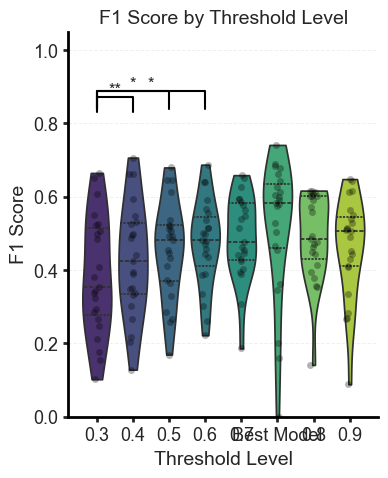

In [26]:
from snnTorch.generalization_madrid.utils import holm_bonferroni

# Define shared color palette for consistency across plots
# Get viridis colors based on number of thresholds (will be determined dynamically)
def get_threshold_colors(adapt_values):
    """Get consistent viridis colors for thresholds."""
    return sns.color_palette("viridis", len(adapt_values))

def plot_f1_boxplot_by_adapt(df, metric="F1", aggregate_by_network=False,aggregate_by_session=False,model=None,thresholds_to_include=None,figsize=(5,6),best_model=None,best_threshold=None):

    threshold_values=thresholds_to_include if thresholds_to_include is not None else sorted(df["Threshold"].unique())
    model=[model] if model is not None else df["Model"].unique()
    print(f"Filtering for model(s): {model} and thresholds: {threshold_values}")
    mask= ((df["Model"].isin(model)) & (df["Threshold"].isin(threshold_values)))
    df = df[mask]

    if best_model is not None and best_threshold is not None:
        df_best_model=df[(df["Model"]==best_model) & (df["Threshold"]==best_threshold)][[metric,"Session"]].reset_index()
    if aggregate_by_session:
        plot_df = df.groupby(["Session", "Threshold"])[metric].median().reset_index()
    else:
        plot_df = df    

    if best_model is not None and best_threshold is not None:
        best_df = df_best_model.copy()
        best_df["Threshold"] = "Best Model"
        plot_df = pd.concat([plot_df, best_df], ignore_index=True)
        threshold_values=[0.3, 0.4, 0.5, 0.6, 0.7, "Best Model", 0.8, 0.9]
  


    fig, ax = plt.subplots(figsize=figsize)
    
    # Boxplot
    # sns.boxplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.8, inner="quart", cut=0, order=threshold_values)
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=threshold_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session"]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    p_values=[]
    pairs=[]
    if len(pivot) > 0:
        centers = range(len(threshold_values))
        # Calculate max height for annotations
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(threshold_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = threshold_values[i]
            a2 = threshold_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                p_values.append(p)
                pairs.append((a1, a2))

                
                # Stacking logic for brackets
                # h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                # print(f"{a1} vs {a2}: p={p:.4f}")
                # barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
            
        corrected_significant, adjusted_pvals=utils.holm_bonferroni(p_values,alpha=0.05)
        for p,sig,(b1,b2) in zip(adjusted_pvals,corrected_significant,pairs):        
                print(f"{b1} vs {b2}: p={p:.4f} {sig}")          
                barplot_annotate_brackets(threshold_values.index(b1), threshold_values.index(b2), p, centers, [max_val+0.05]*len(centers), ax, fs=12, maxasterix=3)   

    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)   
   
    ax.set_title(f"{metric} Score by Threshold Level",fontsize=14)
    ax.set_ylim(0, 1.05) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threshold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')

    plt.show()
    return fig,ax
if 'df' in locals():
   fig,ax = plot_f1_boxplot_by_adapt(df, "F1", aggregate_by_session=True,figsize=(4,5),best_model= "ripplenet_unidirectional_best_random_seed456",best_threshold=0.7)
   fig.savefig(os.path.join("figures", "f1_by_threshold_boxplot_RippleNET.svg"), format="svg", bbox_inches="tight")

Filtering for model(s): ['ripplenet_bidirectional_best_random_seed123'
 'ripplenet_bidirectional_best_random_seed456'
 'ripplenet_bidirectional_best_random_seed789'
 'ripplenet_bidirectional_random_seed123'
 'ripplenet_bidirectional_random_seed456'
 'ripplenet_bidirectional_random_seed789'
 'ripplenet_unidirectional_best_random_seed123'
 'ripplenet_unidirectional_best_random_seed456'
 'ripplenet_unidirectional_best_random_seed789'
 'ripplenet_unidirectional_random_seed123'
 'ripplenet_unidirectional_random_seed456'
 'ripplenet_unidirectional_random_seed789'] and thresholds: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


Precision    Recall
Threshold                          
0.3       0.25   0.162706  0.831975
          0.50   0.237434  0.931655
          0.75   0.426010  0.955295
0.4       0.25   0.210463  0.799924
          0.50   0.288476  0.899281

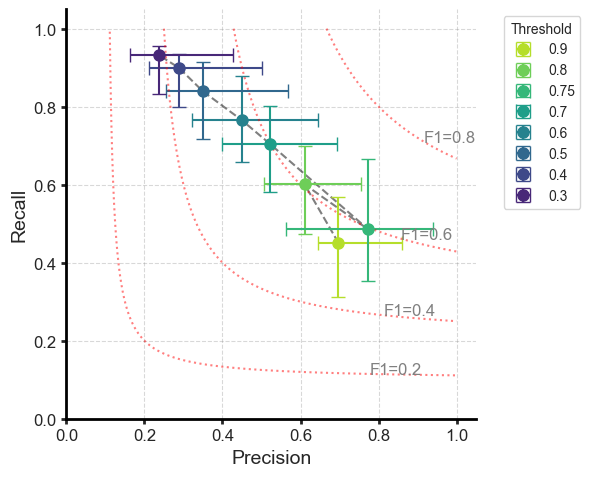

In [25]:
def plot_precision_recall_curve(df, thresholds_to_include=None, aggregate_by_session=True,model=None,best_model=None,best_threshold=None):
    # Filter for specific buffer size if needed, e.g., buffer=6

    threshold_values=thresholds_to_include if thresholds_to_include is not None else sorted(df["Threshold"].unique())
    model=[model] if model is not None else df["Model"].unique()
    print(f"Filtering for model(s): {model} and thresholds: {threshold_values}")
    mask= ((df["Model"].isin(model)) & (df["Threshold"].isin(threshold_values)))

    

    df_subset = df[mask].copy()
    
    if best_model is not None and best_threshold is not None:
        df_best_model=df_subset[(df_subset["Model"]==best_model) & (df_subset["Threshold"]==best_threshold)][["Precision", "Recall","Session"]].reset_index()
    
    if aggregate_by_session:
        df_subset = df_subset.groupby(["Session", "Threshold"])[["Precision", "Recall"]].median().reset_index()
 

    if best_model is not None and best_threshold is not None:
        best_df = df_best_model.copy()
        best_df["Threshold"] = 0.75
        df_subset= pd.concat([df_subset, best_df], ignore_index=True)
        threshold_values=[0.3, 0.4, 0.5, 0.6, 0.7,0.75, 0.8,  0.9]
        
    # Calculate median (50%), 25%, and 75% quantiles
    summary = df_subset.groupby("Threshold")[["Precision", "Recall"]].quantile([0.25, 0.5, 0.75]) # one row per threshold per quantile
    display(summary.head())
    # Sort index appropriately for plotting logic
    # Unstack to get columns like (Precision, 0.5), (Precision, 0.25) ...
    summary = summary.unstack(level=1) # create multi-index columns # Metric, Quantile
    # display(summary.head()  )
    # Extract Medians as the central point
    means = summary.xs(0.5, axis=1, level=1).sort_index(ascending=False) # Extract median values (Threshold, Metric)
    # display(means.head())

    # Calculate IQR errors:
    # lower_err = median - Q1
    # upper_err = Q3 - median
    q1 = summary.xs(0.25, axis=1, level=1).sort_index(ascending=False) # Extract Q1 values (Threshold, Metric)
    q3 = summary.xs(0.75, axis=1, level=1).sort_index(ascending=False) # Extract Q3 values (Threshold, Metric)
    
    # Define errors for errorbar plot (shape: 2xN for each point [lower, upper])
    # Precision Errors
    prec_err_lower = means["Precision"] - q1["Precision"]
    prec_err_upper = q3["Precision"] - means["Precision"]
    
    # Recall Errors
    rec_err_lower = means["Recall"] - q1["Recall"]
    rec_err_upper = q3["Recall"] - means["Recall"]
    
    thresholds = means.index.values

    fig,ax=plt.subplots(figsize=(6,6))
    
    # Plot the line connecting the medians
    ax.plot(means["Precision"], means["Recall"], 'k--', alpha=0.5)
    
    # Plot points with IQR error bars
    sorted_thresholds = sorted(thresholds)
    # Use same viridis colors as cell 8
    colors = get_threshold_colors(sorted_thresholds)
    color_map = {th: col for th, col in zip(sorted_thresholds, colors)}
    
    for i, th in enumerate(thresholds):
        # Prepare error arrays (needs to be sequence of shape (2, 1) or scalar if symmetric, but here asymmetric)
        xerr = [[prec_err_lower[th]], [prec_err_upper[th]]]
        yerr = [[rec_err_lower[th]], [rec_err_upper[th]]]
        
        ax.errorbar(means.loc[th, "Precision"], means.loc[th, "Recall"], 
                     xerr=xerr, 
                     yerr=yerr, 
                     fmt='o', color=color_map[th], 
                     capsize=5, label=f'{th}', markersize=8)

    # Add F1 isolines for reference
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0, 1, 10000)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        valid = (y > 0) & (y < 1)
        ax.plot(x[valid], y[valid], 'r:', linewidth=1.5,alpha=0.5)
        if any(valid):
            ax.text(x[valid][int(len(x[valid])*0.75)], y[valid][int(len(y[valid])*0.75)], f"F1={f1}", color='gray', fontsize=12)

    ax.set_xlabel("Precision",fontsize=14)
    ax.set_ylabel("Recall",fontsize=14)
    ax.set_xlim(0,1.05)
    ax.set_ylim(0,1.05)
    
    # Set Aspect Ratio to be Equal
    ax.set_aspect('equal', adjustable='box')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2,bottom=True, left=True)
    ax.grid(True, which='major', axis='both', linestyle='--', color='gray', alpha=0.3)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Threshold")
    plt.tight_layout()
    plt.show()  
    return fig,ax
fig,ax = plot_precision_recall_curve(df,
                                     best_model="ripplenet_unidirectional_best_random_seed456",best_threshold=0.7
                                    #  model="ripplenet_unidirectional_best_random_seed456"
                                     )
fig.savefig(os.path.join("figures", "precision_recall_curve_RippleNET.svg"), format="svg", bbox_inches="tight")

C:\Users\NCN\AppData\Local\Temp\ipykernel_6088\2151973628.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
C:\Users\NCN\AppData\Local\Temp\ipykernel_6088\2151973628.py:23: UserWarning: 
The palette list has fewer values (4) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)


0.3 vs 0.4: p=0.0003
0.3 vs 0.5: p=0.0008
0.3 vs 0.6: p=0.0031
0.3 vs 0.7: p=0.0112
0.3 vs 0.8: p=0.0327
0.3 vs 0.9: p=0.1424
0.4 vs 0.5: p=0.0067
0.4 vs 0.6: p=0.0233
0.4 vs 0.7: p=0.0484
0.4 vs 0.8: p=0.1511
0.4 vs 0.9: p=0.5009
0.5 vs 0.6: p=0.0918
0.5 vs 0.7: p=0.1695
0.5 vs 0.8: p=0.4634
0.5 vs 0.9: p=0.9881
0.6 vs 0.7: p=0.3931
0.6 vs 0.8: p=0.7998
0.6 vs 0.9: p=0.5600
0.7 vs 0.8: p=0.6221
0.7 vs 0.9: p=0.1341
0.8 vs 0.9: p=0.0301


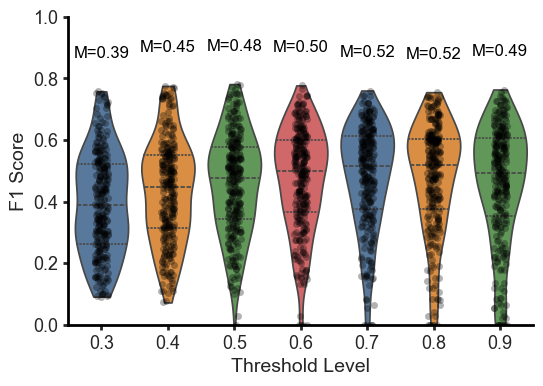

In [12]:
def plot_f1_violin_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())

    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Threshold"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(6, 4))
    
    colors=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]

    # Violin plot
    sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel",]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    # display(pivot.head())
    pivot = pivot.dropna()

    # Annotate medians and N
    medians = plot_df.groupby('Threshold')[metric].median()
    counts = plot_df.groupby('Threshold')[metric].count()
    mins=plot_df.groupby('Threshold')[metric].min() 
    maxs=plot_df.groupby('Threshold')[metric].max()    
    for i, adapt in enumerate(adapt_values):
        if adapt in medians:
            val = medians[adapt]
            max_val = maxs[adapt]
            ax.text(i, max_val+ 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    if len(pivot) > 0:
        centers = range(len(adapt_values))
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3: 
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                print(f"{a1} vs {a2}: p={p:.4f}")
                # barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
                
    # ax.set_title(f"{metric} Distribution by Adaptation Level{title_suffix}")
    ax.set_ylim(0,1) 

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(1.3)
    ax.spines[['bottom','left']].set_color('black')
    # ax.set_xticklabels(["Fixed","60", "10", "1"])
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2)
    ax.tick_params(axis='x', rotation=0)

    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threshold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()
    return fig,ax

if 'df' in locals():
    fig,ax=plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    os.makedirs("figures", exist_ok=True)
    # fig.savefig("figures/f1_violin_by_adapt.svg", dpi=300, bbox_inches='tight')
    # fig.savefig("figures/f1_violin_by_adapt.png",dpi=300)

C:\Users\NCN\AppData\Local\Temp\ipykernel_6088\1127962853.py:28: RuntimeWarning: divide by zero encountered in divide
  y = (f1 * x) / (2 * x - f1)


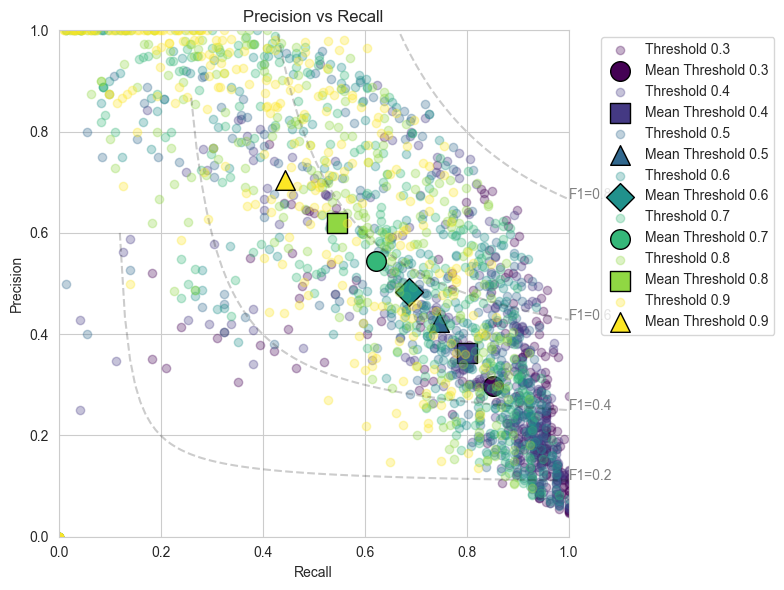

In [13]:
def plot_precision_recall(df):
    plt.figure(figsize=(8, 6))
    
    #  # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())
    
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.viridis(np.linspace(0, 1, len(adapt_values)))
    
    for i, adapt in enumerate(adapt_values):
        subset = df[df["Threshold"] == adapt]
        
        # Mean point
        mean_p = subset["Precision"].mean()
        mean_r = subset["Recall"].mean()
        
        plt.scatter(subset["Recall"], subset["Precision"], label=f"Threshold {adapt}", alpha=0.3, color=colors[i])
        plt.scatter(mean_r, mean_p, s=200, edgecolor='black', marker=markers[i%len(markers)], 
                    label=f"Mean Threshold {adapt}", color=colors[i])
        
    # F1 isolines
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0.01, 1, 100)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        # Filter valid y
        valid = (y >= 0) & (y <= 1)
        plt.plot(x[valid], y[valid], 'k--', alpha=0.2)
        if any(valid):
            plt.text(x[valid][-1], y[valid][-1], f"F1={f1}", color='gray')
        
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if 'df' in locals():
    plot_precision_recall(df)

C:\Users\NCN\AppData\Local\Temp\ipykernel_6088\1415075225.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Threshold", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)


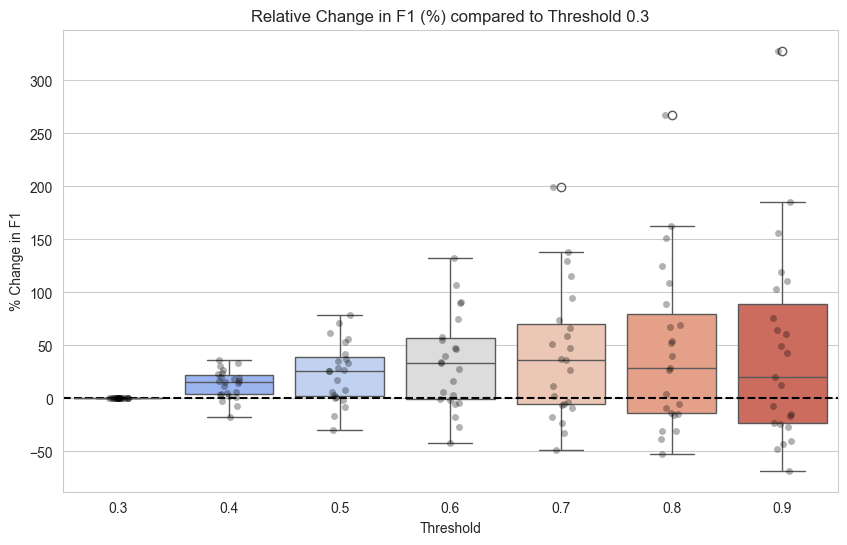

In [14]:
def plot_relative_change(df, metric="F1"):
    # Pivot to have Adapt as columns
    pivot_cols = ["Session", "Channel",]
    if "Dataset" in df.columns:
        pivot_cols.append("Dataset")
        
    pivot = df.pivot_table(index=pivot_cols, columns="Threshold", values=metric) # Pivot table
    # print(pivot.head())
    # Calculate change relative to Adapt 0 (or lowest adapt value)
     # Define specific order
    desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values= sorted(df["Threshold"].unique())
    baseline_adapt = 0.3
    
    if baseline_adapt not in pivot.columns:
        print(f"Baseline adapt {baseline_adapt} not found in pivot columns.")
        return

    changes = pd.DataFrame()
    for col in pivot.columns:
        changes[col] = (pivot[col] - pivot[baseline_adapt]) / pivot[baseline_adapt] * 100
        
    # Melt for plotting
    melted = changes.melt(var_name="Threshold", value_name="Percent Change")
    # print(melted)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Threshold", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y="Percent Change", data=melted, color="black", alpha=0.3, jitter=True, order=adapt_values)

    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Relative Change in {metric} (%) compared to Threshold {baseline_adapt}")
    plt.ylabel(f"% Change in {metric}")
    plt.show()

if 'df' in locals():
    plot_relative_change(df, "F1")

,Session,Channel,Threshold,Metric,Value
0,2025-09-22_17-42-27,24,0.3,Precision,0.304688
1,2025-09-22_17-42-27,24,0.3,Precision,0.330508
2,2025-09-22_17-42-27,24,0.3,Precision,0.289474
3,2025-09-22_17-42-27,24,0.3,Precision,0.400000
4,2025-09-22_17-42-27,24,0.3,Precision,0.307692


C:\Users\NCN\AppData\Local\Temp\ipykernel_6088\2978468147.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)


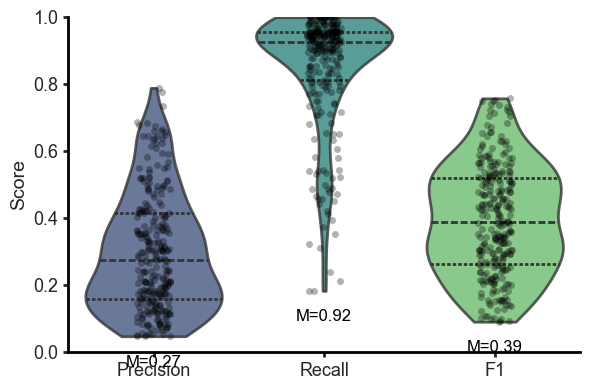

In [15]:
# Plot Precision, Recall and F1 for a single Adaptation level in the same figure
def plot_metrics_single_adapt(df, adapt=20, aggregate_by_network=False, metrics=("Precision", "Recall", "F1")):
    """Plot the distributions of multiple metrics for a single `adapt` value in one plot."""
    # Ensure adapt exists in the dataframe
    if adapt not in df["Threshold"].unique():
        print(f"Adapt {adapt} not present in dataframe. Available: {sorted(df['Threshold'].unique())}")
        return

    # Prepare data for the requested adapt
    if aggregate_by_network:
        agg_cols = ['Network', 'Adapt']
        plot_df = df.groupby(agg_cols)[list(metrics)].mean().reset_index()
        title_suffix = ' (Averaged by Network)'
    else:
        plot_df = df.copy()
        title_suffix = ''

    plot_df = plot_df[plot_df['Threshold'] == adapt]
    if len(plot_df) == 0:
        print(f'No rows for Threshold {adapt} after filtering.')
        return

    # Melt metrics into long form for plotting
    id_vars = [c for c in ['Session', 'Channel', 'Threshold'] if c in plot_df.columns]
    melted = plot_df.melt(id_vars=id_vars, value_vars=list(metrics), var_name='Metric', value_name='Value')
    display(melted.head())
    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    order = list(metrics)
    sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)
    sns.stripplot(x='Metric', y='Value', data=melted, ax=ax, color='k', alpha=0.3, jitter=True, order=order)

    # Annotate medians and N
    medians = melted.groupby('Metric')['Value'].median()
    counts = melted.groupby('Metric')['Value'].count()
    mins=melted.groupby('Metric')['Value'].min() 
    
    for i, metric in enumerate(order):
        if metric in medians:
            val = medians[metric]
            min_val = mins[metric]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    ax.set_ylim(0, 1)
    # ax.set_title(f'Performance Metrics', fontsize=14)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_xlabel('')
    # ax.set_xlabel('Metric', fontsize=14)
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')

    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)
    # ax.set_yticks(np.arange(0.3, 1.1, 0.1))
    plt.tight_layout()
    plt.show()
    return fig, ax

if 'df' in locals():
    fig,ax=plot_metrics_single_adapt(df, adapt=0.3, aggregate_by_network=False)
    # plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    # fig.savefig("figures/metrics_single_adapt.svg", format="svg")
    # fig.savefig("figures/metrics_single_adapt.png", format="png", dpi=300)

Optimizing metrics over: ['Threshold', 'Model']
Original rows: 1932, Optimized rows: 23

--- Optimized Performance Summary (Best Threshold Per Session) ---


,F1,Precision,Recall
count,23.000,23.000,23.000
mean,0.662,0.687,0.653
std,0.086,0.110,0.108
min,0.430,0.410,0.442
25%,0.626,0.636,0.560
50%,0.655,0.702,0.663
75%,0.725,0.764,0.720
max,0.781,0.855,0.850


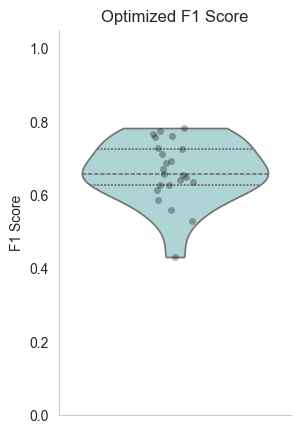

In [16]:
# Compute the performance considering the best configuration per session
def compute_best_performance(df, metric="F1", optimize=["Threshold", "Model", "Network"], average_over=["Channel"]):
    """
    Computes the best performance for each session by selecting the configuration (Threshold, Model, etc.)
    that maximizes the given metric.
    """
    # 1. Validate columns
    optimize = [col for col in optimize if col in df.columns]
    
    if not optimize:
        print("No columns to optimize found.")
        return df

    print(f"Optimizing metrics over: {optimize}")

    # 2. Group by Session and Optimization parameters to find mean performance (e.g. across channels)
    group_cols = ["Session"] + optimize
    
    # Calculate the mean score of the target metric for each configuration
    performance_per_config = df.groupby(group_cols)[metric].mean().reset_index()

    # 3. select the best configuration for each session
    best_configs = performance_per_config.sort_values(by=[metric], ascending=False).drop_duplicates(subset=["Session"])

    # 4. Merge back to get the full rows (metrics per channel) for the best configs
    best_performance_df = df.merge(best_configs[group_cols], on=group_cols, how="inner")
    
    # Print stats
    print(f"Original rows: {len(df)}, Optimized rows: {len(best_performance_df)}")
    
    return best_performance_df

if 'df' in locals():
    # Run optimization (Optimizing Threshold)
    df_opt = compute_best_performance(df, optimize=["Threshold","Model"])
    
    # Show Summary
    print("\n--- Optimized Performance Summary (Best Threshold Per Session) ---")
    display(df_opt[["F1", "Precision", "Recall"]].describe().round(3))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(3, 5))
    sns.violinplot(y="F1", data=df_opt, color="#a8dadc", inner="quartile", ax=ax, cut=0)
    sns.stripplot(y="F1", data=df_opt, color="black", alpha=0.3, ax=ax)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1 Score")
    ax.set_title("Optimized F1 Score")
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()